## HSRL-2 vs TOLNet Comparison
Scatter plots comparing HSRL-2 airborne lidar ozone profiles against each TOLNet ground-based lidar site.
- **x-axis**: TOLNet O₃ (ppbv)
- **y-axis**: HSRL-2 O₃ (ppbv)
- **color**: HSRL-2 distance from TOLNet site (km)
- One figure per TOLNet site

In [11]:
# Housekeeping
from pathlib import Path
import pickle

# Data Processing
import pandas as pd
import numpy as np

# Geospatial
import geopandas as gpd
from shapely.geometry import Point

# Math and Stats
from scipy.stats import linregress

# Plotting
import matplotlib.pyplot as plt

# Custom Modules
from atmoz.resources.path_manager import PathManager
import atmoz.resources.importData as importData
import atmoz.resources.geoSlicing as geoSlicing
import atmoz.resources.makePlots as makePlots

### Load Data

In [12]:
import json 

with open("../paths.json", "r") as f: 
    paths = json.load(f) 

data_dir = Path(paths["Laptop_Linux"]["path_datasets"])
fig_dir  = Path(paths["Laptop_Linux"]["path_figures"])

data   = importData.main_import(data_dir)
tolnet = data["tolnet"].copy()
hsrl2  = data["hsrl2"].copy()

print(f"TOLNet files: {len(tolnet)}")
print(f"HSRL-2 files: {len(hsrl2)}")

TOLNet files: 85
HSRL-2 files: 15


### Site Lookup Dictionaries

In [13]:
instrument_names = {
    "csl001_hires_guilford":   "NOAA CSL Lidar",
    "gsfc003_hires_oldfield":  "NASA GSFC Lidar",
    "gsfc003_hires":           "NASA GSFC Lidar",
    "csl001_hires_boulder":    "NOAA CSL Lidar",
    "york":                    "CCNY Lidar",
    "larc001_hires_sherwood":  "NASA LaRC Lidar",
}

instrument_locations = {
    "csl001_hires_guilford":   "Yale Coastal (Guilford CT)",
    "gsfc003_hires_oldfield":  "Flax Pond NY",
    "gsfc003_hires":           "Flax Pond NY",
    "csl001_hires_boulder":    "Boulder CO",
    "york":                    "CCNY Rooftop",
    "larc001_hires_sherwood":  "LaRC Sherwood",
}

### Helpers

In [14]:
# Common altitude grid: 0–10 km in 500 m bins
common_grid = np.arange(0, 10_500, 500).astype(float)  # meters


def align_lidar_to_common_grid(df: pd.DataFrame, grid_m: np.ndarray) -> pd.DataFrame:
    """Interpolate lidar GeoDataFrame (columns=altitude_m) onto grid_m.

    Returns DataFrame with index=timestamps, columns=grid_m, values=ozone.
    No extrapolation: values outside the instrument's altitude range are NaN.
    """
    data_only = df.drop(columns="geometry", errors="ignore").astype(float)
    src_alts  = data_only.columns.astype(float).values

    out = np.full((len(data_only), len(grid_m)), np.nan)
    vals = data_only.values

    for i in range(len(data_only)):
        row = vals[i]
        valid = np.isfinite(row)
        if valid.sum() < 2:
            continue
        out[i] = np.interp(
            grid_m,
            src_alts[valid],
            row[valid],
            left=np.nan,
            right=np.nan,
        )

    return pd.DataFrame(out, index=data_only.index, columns=grid_m)

### Build Comparison Cache
For each (TOLNet site, HSRL-2 file) pair:
1. Spatial filter: keep HSRL-2 profiles within 50 km of the TOLNet site
2. Temporal filter: keep TOLNet profiles within ±30 min of the HSRL-2 overpass window

In [15]:
SPATIAL_RADIUS_KM = 50
TIME_TOLERANCE    = "30 min"

cache_path = data_dir / "hsrl2_vs_tolnet_comparison.pkl"

if cache_path.is_file():
    with open(cache_path, "rb") as f:
        comparison = pickle.load(f)
    print(f"Loaded comparison cache: {len(comparison)} pairs")
else:
    comparison = {}

    for tolnet_key, tolnet_gdf in tolnet.items():
        site_location = tolnet_gdf.geometry.iloc[0]

        for hsrl2_key, hsrl2_gdf in hsrl2.items():

            # -- Spatial filter --
            hsrl2_with_dist = geoSlicing._add_distance_from_point(hsrl2_gdf, site_location)
            nearby = hsrl2_with_dist[hsrl2_with_dist["distance_km"] <= SPATIAL_RADIUS_KM]
            if nearby.empty:
                continue

            # -- Temporal match: window anchored to the HSRL-2 overpass span --
            matched = makePlots._match_time(
                left_df  = nearby.drop(columns="geometry"),
                right_df = tolnet_gdf.drop(columns="geometry"),
                tolerance=TIME_TOLERANCE,
                rounding="10 min",
                align="left",
            )
            if matched["left_df"].empty or matched["right_df"].empty:
                continue

            comparison[(tolnet_key, hsrl2_key)] = matched
            print(f"  Matched: {tolnet_key.split('.')[2]} × {hsrl2_key}  "
                  f"({len(matched['left_df'])} HSRL-2, {len(matched['right_df'])} TOLNet profiles)")

    with open(cache_path, "wb") as f:
        pickle.dump(comparison, f)
    print(f"\nSaved {len(comparison)} matched pairs to cache.")

Loaded comparison cache: 19 pairs


### Build Altitude-Aligned Regression Dataset
For each matched pair:
- Interpolate both profiles to the common altitude grid
- Average all TOLNet profiles within the overpass window → one representative TOLNet profile
- Pair each HSRL-2 profile point (timestamp × altitude) against the mean TOLNet profile at the same altitude

In [16]:
regression = {}  # key: instrument_key (e.g. "csl001_hires_guilford")

for (tolnet_key, hsrl2_key), matched in comparison.items():

    instrument_key = tolnet_key.split(".")[2]

    # -- HSRL-2: drop distance_km, align to common grid (already in ppbv) --
    hsrl2_slice   = matched["left_df"].drop(columns=["distance_km"], errors="ignore")
    hsrl2_dist    = matched["left_df"]["distance_km"] if "distance_km" in matched["left_df"].columns else None
    hsrl2_aligned = align_lidar_to_common_grid(hsrl2_slice, common_grid)

    # -- TOLNet: convert ppmv → ppbv, then align --
    tolnet_ppbv    = matched["right_df"] * 1000
    tolnet_aligned = align_lidar_to_common_grid(tolnet_ppbv, common_grid)
    tolnet_mean    = tolnet_aligned.mean(axis=0)   # one mean profile per overpass window

    # -- Build long-form pair table: one row per (HSRL-2 timestamp × altitude bin) --
    records = []
    for ts, row in hsrl2_aligned.iterrows():
        dist = (
            hsrl2_dist.loc[ts]
            if (hsrl2_dist is not None and ts in hsrl2_dist.index)
            else np.nan
        )
        for alt_m in common_grid:
            h_val = row[alt_m]
            t_val = tolnet_mean[alt_m]
            if np.isnan(h_val) or np.isnan(t_val):
                continue
            records.append({
                "hsrl2_ozone":  h_val,
                "tolnet_ozone": t_val,
                "altitude_km":  alt_m / 1000,
                "distance_km":  dist,
                "timestamp":    ts,
            })

    if records:
        regression.setdefault(instrument_key, []).append(pd.DataFrame(records))

for k in regression:
    regression[k] = pd.concat(regression[k], ignore_index=True)

print("Points per site:")
for k, df in regression.items():
    print(f"  {k}: {len(df)} pairs")

Points per site:
  york: 46472 pairs
  gsfc003_hires: 34354 pairs
  gsfc003_hires_oldfield: 31570 pairs
  larc001_hires_sherwood: 7442 pairs
  csl001_hires_guilford: 13924 pairs


### Scatter Plots — HSRL-2 vs TOLNet (one per site, all distances)

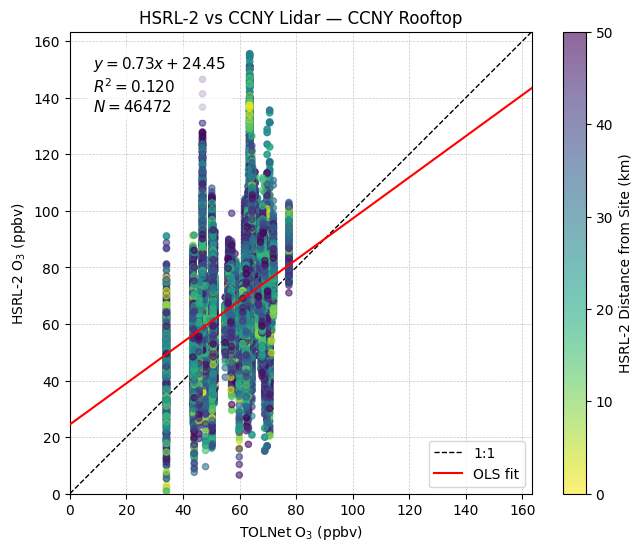

Saved: HSRL-2_vs_CCNY_Lidar__CCNY_Rooftop.png


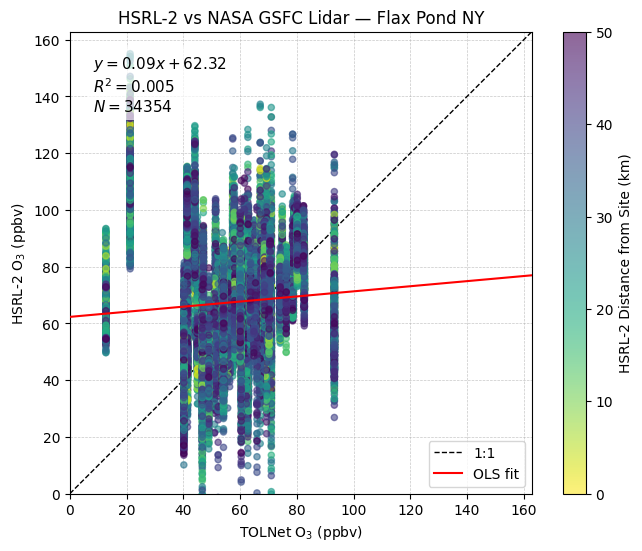

Saved: HSRL-2_vs_NASA_GSFC_Lidar__Flax_Pond_NY.png


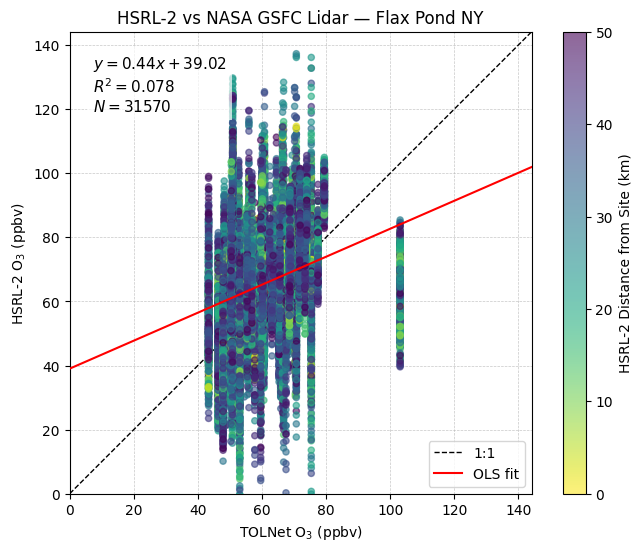

Saved: HSRL-2_vs_NASA_GSFC_Lidar__Flax_Pond_NY.png


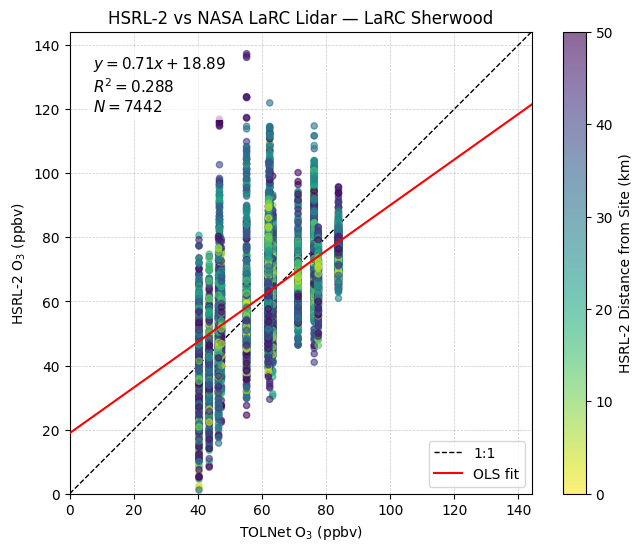

Saved: HSRL-2_vs_NASA_LaRC_Lidar__LaRC_Sherwood.png


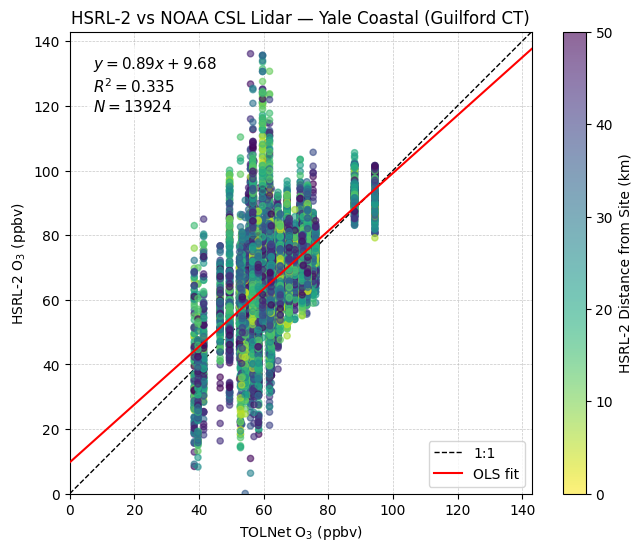

Saved: HSRL-2_vs_NOAA_CSL_Lidar__Yale_Coastal_Guilford_CT.png


In [17]:
save_dir = fig_dir / "hsrl2_vs_tolnet"
save_dir.mkdir(parents=True, exist_ok=True)

for instrument_key, df in regression.items():

    loc_name  = instrument_locations.get(instrument_key, instrument_key)
    inst_name = instrument_names.get(instrument_key, instrument_key)
    title = f"HSRL-2 vs {inst_name} — {loc_name}"

    df_clean = df.dropna(subset=["hsrl2_ozone", "tolnet_ozone", "distance_km"])
    if len(df_clean) < 5:
        print(f"Skipping {instrument_key}: only {len(df_clean)} valid pairs")
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        df_clean["tolnet_ozone"], df_clean["hsrl2_ozone"]
    )

    fig, ax = plt.subplots(figsize=(8, 6))

    sc = ax.scatter(
        df_clean["tolnet_ozone"],
        df_clean["hsrl2_ozone"],
        c     = df_clean["distance_km"],
        cmap  = "viridis_r",
        vmin  = 0,
        vmax  = SPATIAL_RADIUS_KM,
        s     = 20,
        alpha = 0.6,
        zorder= 3,
    )

    upper = max(df_clean["tolnet_ozone"].max(), df_clean["hsrl2_ozone"].max()) * 1.05
    lims  = [0, upper]
    ax.plot(lims, lims, "k--", linewidth=1, label="1:1", zorder=2)

    x_fit = np.linspace(lims[0], lims[1], 200)
    ax.plot(x_fit, slope * x_fit + intercept, "r-", linewidth=1.5, label="OLS fit", zorder=4)

    cbar = fig.colorbar(sc, ax=ax)
    cbar.set_label("HSRL-2 Distance from Site (km)")

    sign    = "+" if intercept >= 0 else "-"
    eq_text = (
        f"$y = {slope:.2f}x {sign} {abs(intercept):.2f}$\n"
        f"$R^2 = {r_value**2:.3f}$\n"
        f"$N = {len(df_clean)}$"
    )
    ax.text(
        0.05, 0.95, eq_text,
        transform=ax.transAxes, fontsize=11, verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
    )

    ax.set_xlabel("TOLNet O$_3$ (ppbv)")
    ax.set_ylabel("HSRL-2 O$_3$ (ppbv)")
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=12)
    ax.legend(loc="lower right")
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

    savename = (
        title.replace(" ", "_").replace("—", "").replace(",", "")
             .replace(".", "_").replace("(", "").replace(")", "")
        + ".png"
    )
    plt.savefig(save_dir / savename, dpi=600, transparent=True, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {savename}")

### Distance Distribution Histograms
For each TOLNet site: histogram of HSRL-2 profile counts by separation distance.
Shaded regions correspond to the regression bins below.
Note: the first two regression bins (`<1 km`, `<10 km`) are **cumulative**; the remaining four are **exclusive**.

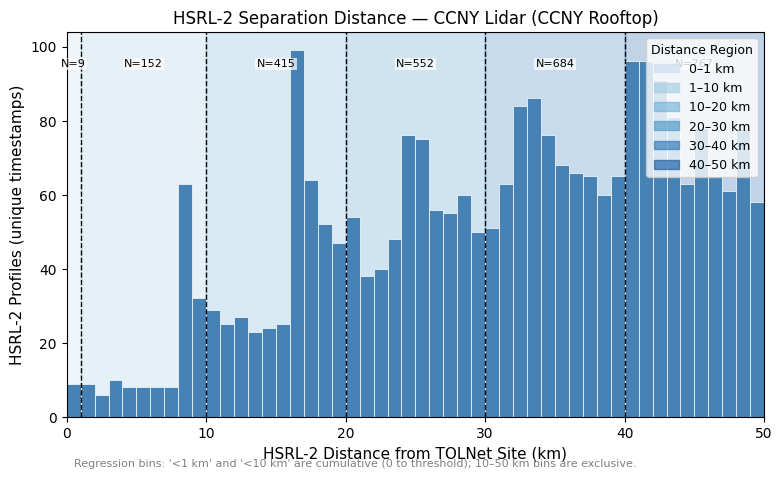

Saved: hist_distance_york.png


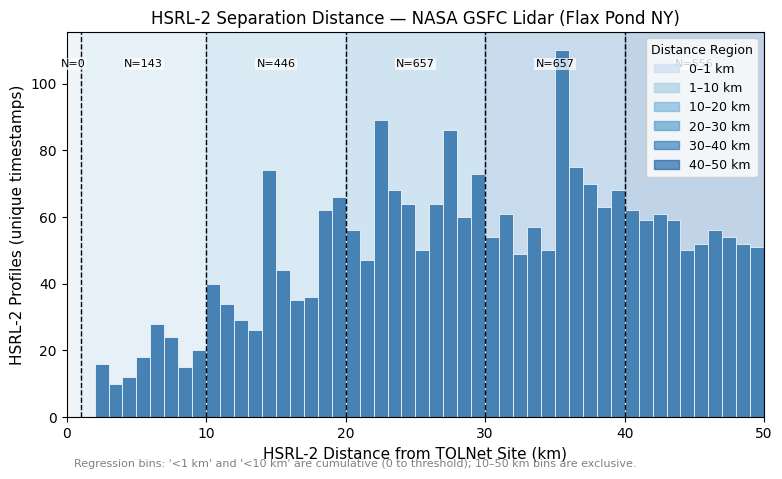

Saved: hist_distance_gsfc003_hires.png


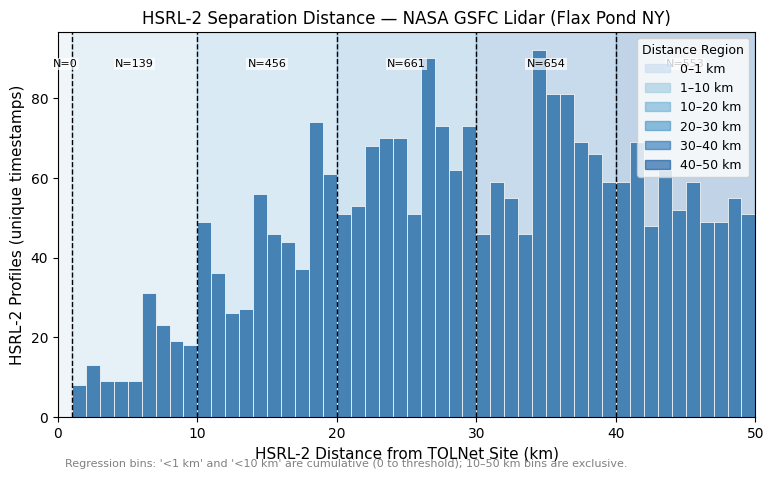

Saved: hist_distance_gsfc003_hires_oldfield.png


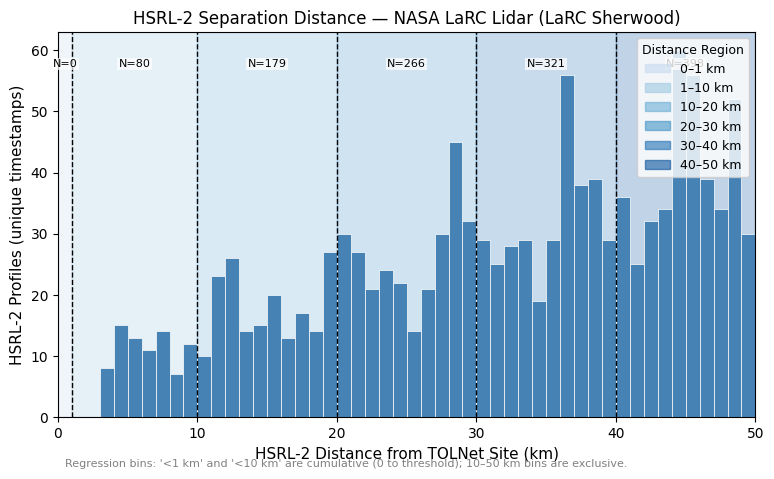

Saved: hist_distance_larc001_hires_sherwood.png


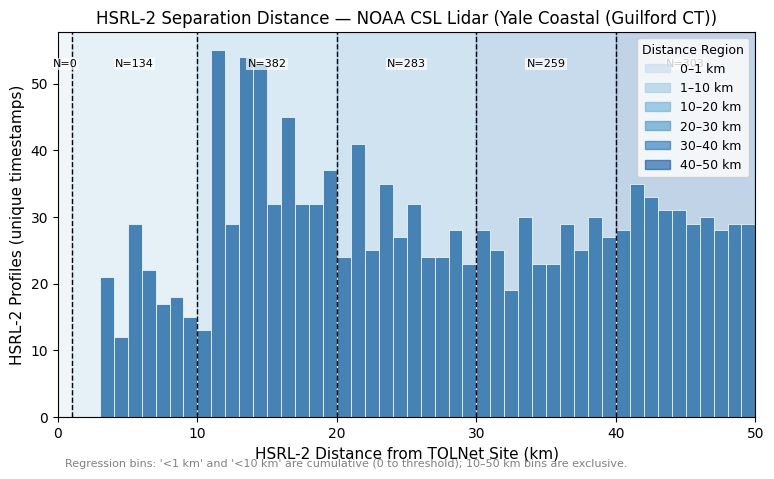

Saved: hist_distance_csl001_hires_guilford.png


In [18]:
# Histogram bin edges and region shading
hist_edges    = [0, 1, 10, 20, 30, 40, 50]
hist_labels   = ["0–1 km", "1–10 km", "10–20 km", "20–30 km", "30–40 km", "40–50 km"]
region_colors = ["#c6dbef", "#9ecae1", "#6baed6", "#4292c6", "#2171b5", "#08519c"]

for instrument_key, df in regression.items():
    loc_name  = instrument_locations.get(instrument_key, instrument_key)
    inst_name = instrument_names.get(instrument_key, instrument_key)
    title = f"HSRL-2 Separation Distance — {inst_name} ({loc_name})"

    # One distance value per HSRL-2 profile timestamp (not per altitude bin)
    unique_dists = (
        df.drop_duplicates(subset=["timestamp"])["distance_km"]
        .dropna()
        .values
    )
    if len(unique_dists) == 0:
        print(f"Skipping {instrument_key}: no distance data")
        continue

    fig, ax = plt.subplots(figsize=(9, 5))

    # Shade background by region
    for i, (lo, hi) in enumerate(zip(hist_edges[:-1], hist_edges[1:])):
        ax.axvspan(lo, hi, color=region_colors[i], alpha=0.25, zorder=0)

    # Histogram: 1 km bins
    ax.hist(
        unique_dists,
        bins=np.arange(0, 51, 1),
        color="steelblue",
        edgecolor="white",
        linewidth=0.5,
        zorder=2,
    )

    # Annotate count in each region
    ymax = ax.get_ylim()[1]
    for i, (lo, hi) in enumerate(zip(hist_edges[:-1], hist_edges[1:])):
        n_reg = int(((unique_dists >= lo) & (unique_dists < hi)).sum())
        ax.text(
            (lo + hi) / 2, ymax * 0.93,
            f"N={n_reg}",
            ha="center", va="top", fontsize=8,
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=1),
            zorder=4,
        )

    # Vertical reference lines at bin boundaries
    for bnd in hist_edges[1:-1]:  # 1, 10, 20, 30, 40 km
        ax.axvline(bnd, color="black", linestyle="--", linewidth=1.0, zorder=3)

    ax.set_xlabel("HSRL-2 Distance from TOLNet Site (km)", fontsize=11)
    ax.set_ylabel("HSRL-2 Profiles (unique timestamps)", fontsize=11)
    ax.set_xlim(0, 50)
    ax.set_title(title, fontsize=12)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=region_colors[i], alpha=0.6)
        for i in range(len(hist_labels))
    ]
    ax.legend(
        handles, hist_labels,
        title="Distance Region",
        loc="upper right", fontsize=9, title_fontsize=9,
    )
    ax.text(
        0.01, -0.13,
        "Regression bins: '<1 km' and '<10 km' are cumulative (0 to threshold); 10–50 km bins are exclusive.",
        transform=ax.transAxes, fontsize=8, color="gray",
    )

    savename = f"hist_distance_{instrument_key}.png"
    plt.savefig(save_dir / savename, dpi=600, transparent=True, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {savename}")

### Distance-Binned Regression Scatter Plots
For each TOLNet site: 6-panel figure showing the HSRL-2 vs TOLNet regression within each distance bin.
- **`<1 km`** and **`<10 km`**: cumulative bins (include all data up to that distance)
- **`10–20`, `20–30`, `30–40`, `40–50 km`**: exclusive bins
- Color encodes altitude (km) to reveal altitude-dependent biases

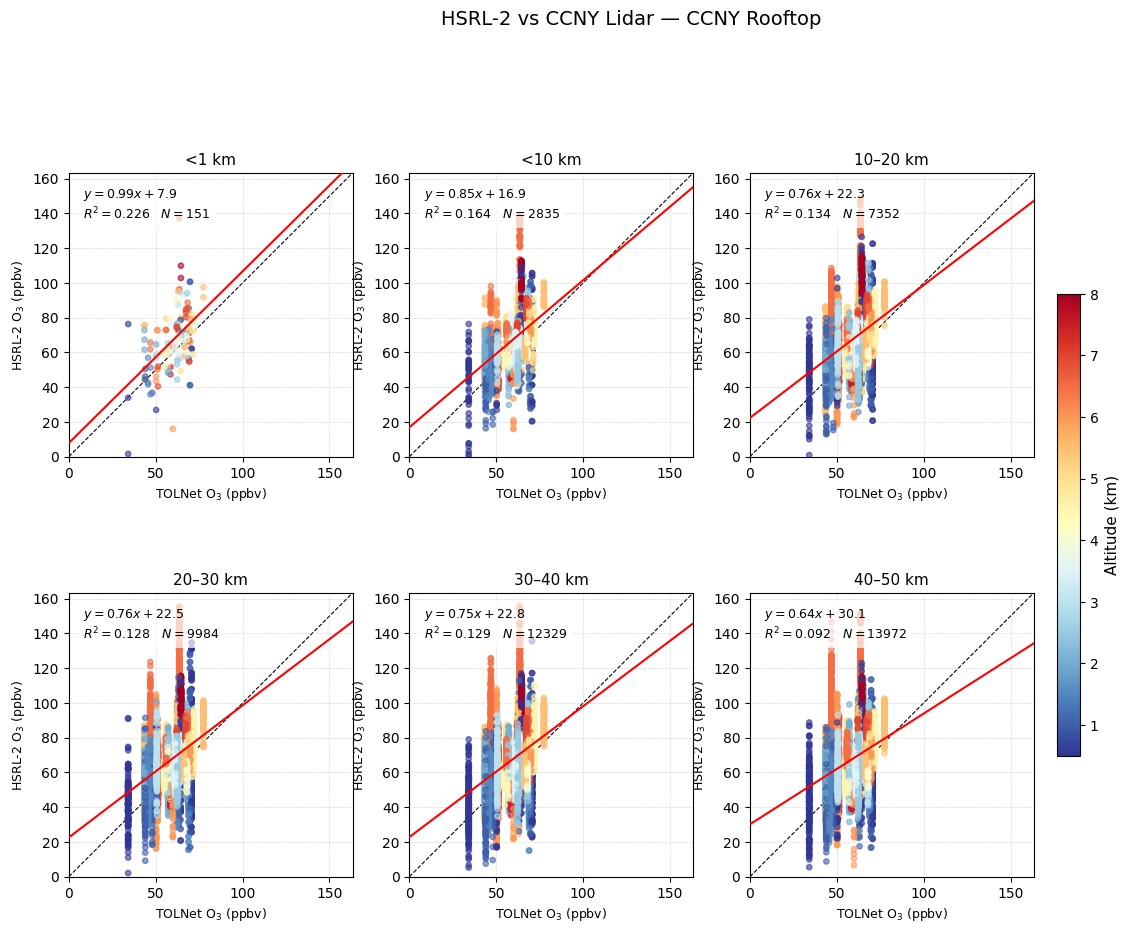

Saved: binned_regression_york.png


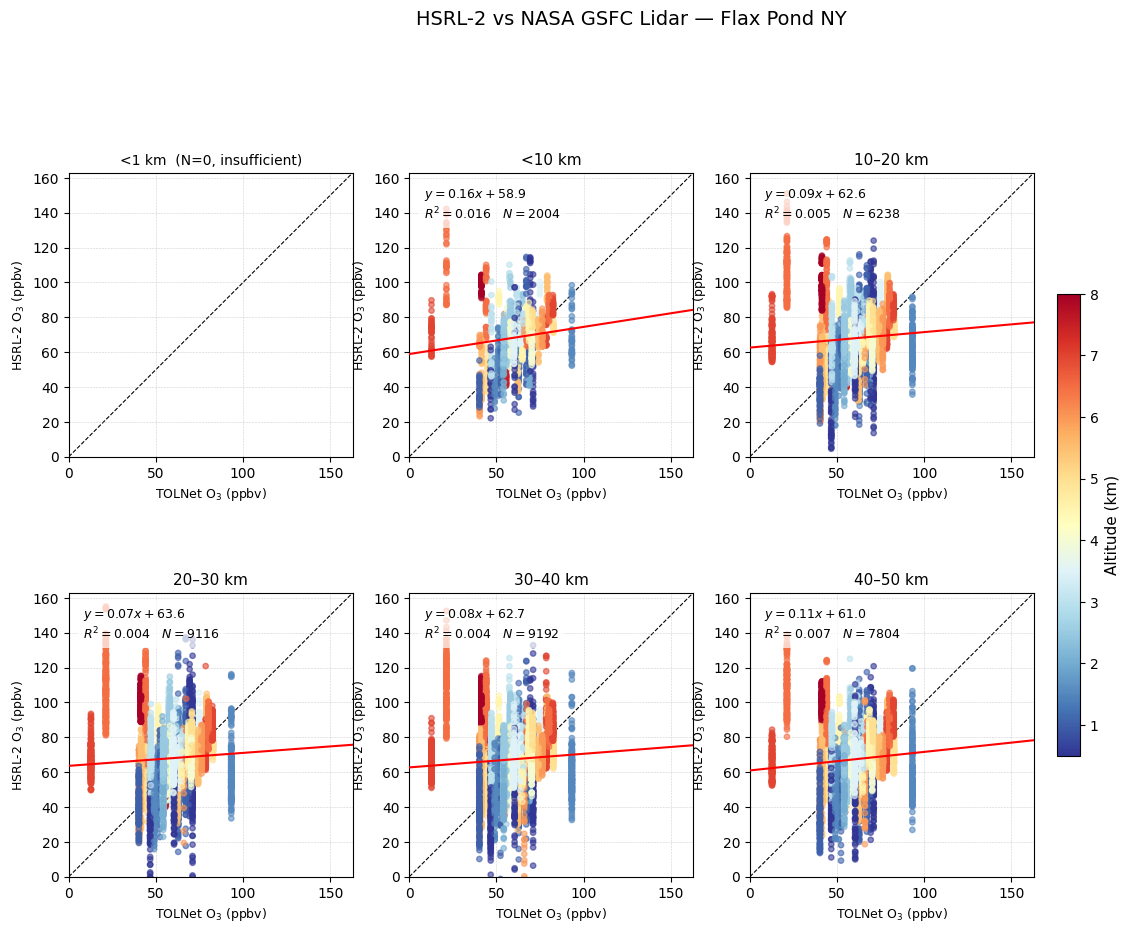

Saved: binned_regression_gsfc003_hires.png


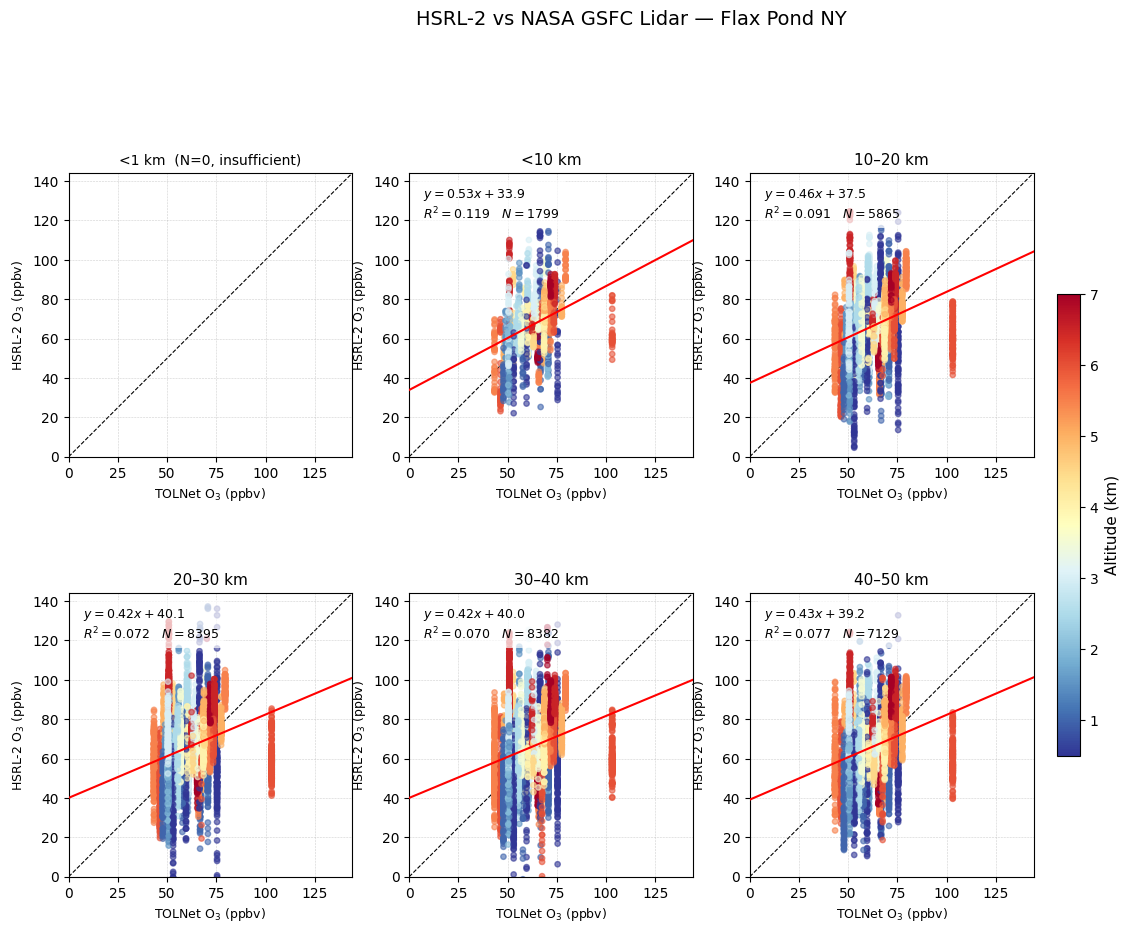

Saved: binned_regression_gsfc003_hires_oldfield.png


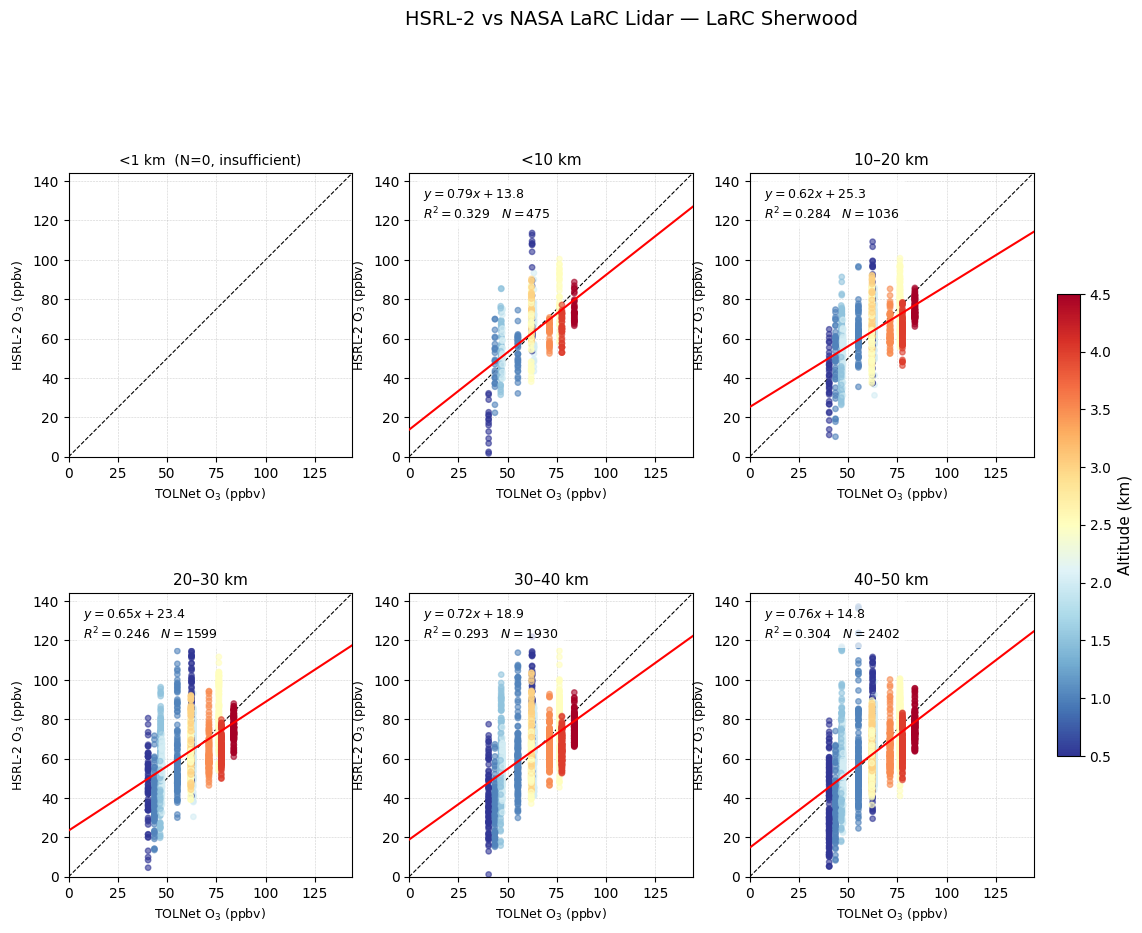

Saved: binned_regression_larc001_hires_sherwood.png


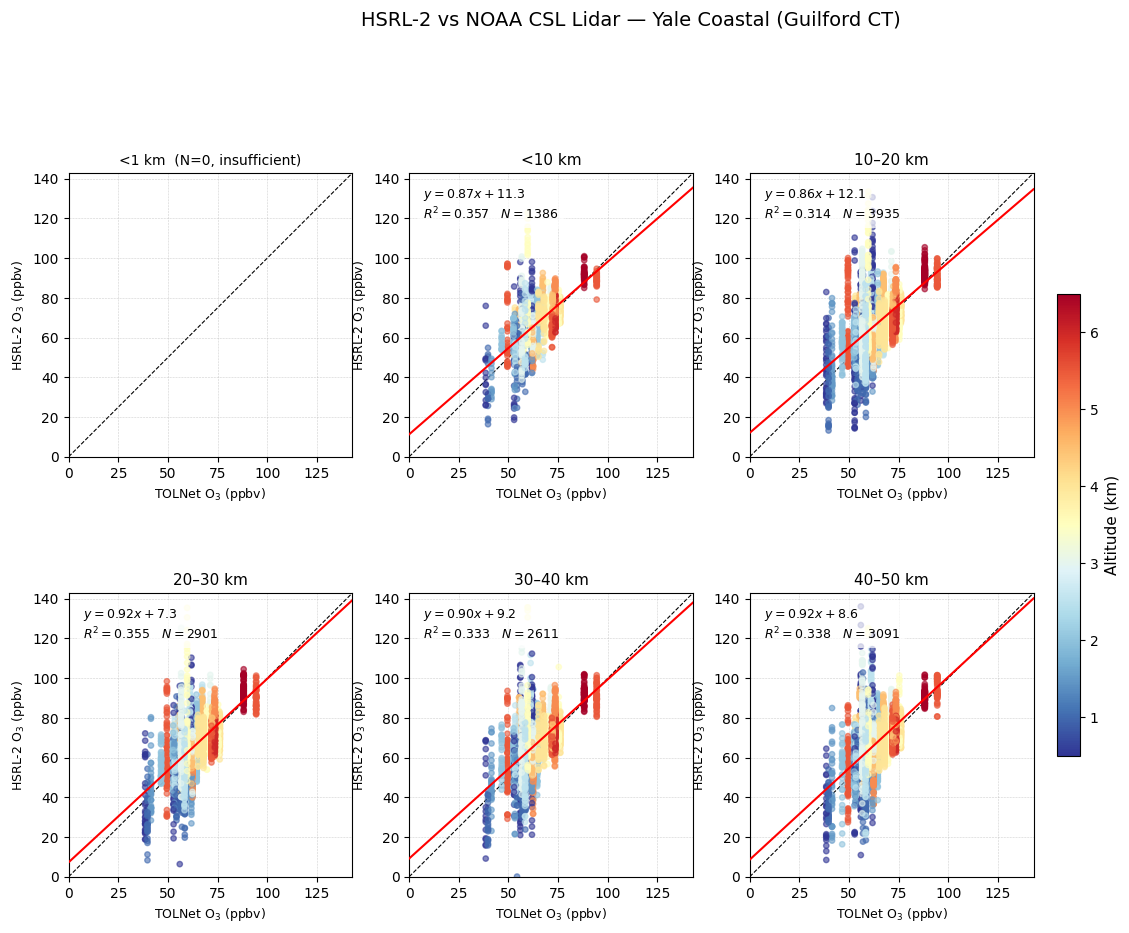

Saved: binned_regression_csl001_hires_guilford.png


In [19]:
distance_bins = [
    ("<1 km",     0,   1),
    ("<10 km",    0,  10),
    ("10–20 km",  10,  20),
    ("20–30 km",  20,  30),
    ("30–40 km",  30,  40),
    ("40–50 km",  40,  50),
]

for instrument_key, df in regression.items():
    loc_name  = instrument_locations.get(instrument_key, instrument_key)
    inst_name = instrument_names.get(instrument_key, instrument_key)
    title     = f"HSRL-2 vs {inst_name} — {loc_name}"

    df_clean = df.dropna(subset=["hsrl2_ozone", "tolnet_ozone", "distance_km"])
    if df_clean.empty:
        print(f"Skipping {instrument_key}: no valid data")
        continue

    # Consistent axis limits across all panels
    upper = max(df_clean["tolnet_ozone"].max(), df_clean["hsrl2_ozone"].max()) * 1.05
    lims  = [0, upper]

    # Altitude colormap
    alt_min = df_clean["altitude_km"].min()
    alt_max = df_clean["altitude_km"].max()
    cmap    = plt.get_cmap("RdYlBu_r")
    norm    = plt.Normalize(vmin=alt_min, vmax=alt_max)

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=14, y=1.01)

    for ax, (bin_label, lo, hi) in zip(axes.flat, distance_bins):

        subset = df_clean[
            (df_clean["distance_km"] >= lo) & (df_clean["distance_km"] < hi)
        ]

        # 1:1 reference line
        ax.plot(lims, lims, "k--", linewidth=0.8, zorder=1, label="1:1")

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("equal")
        ax.set_xlabel("TOLNet O$_3$ (ppbv)", fontsize=9)
        ax.set_ylabel("HSRL-2 O$_3$ (ppbv)", fontsize=9)
        ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.6)

        if len(subset) < 5:
            ax.set_title(f"{bin_label}  (N={len(subset)}, insufficient)", fontsize=10)
            continue

        ax.scatter(
            subset["tolnet_ozone"],
            subset["hsrl2_ozone"],
            c     = subset["altitude_km"],
            cmap  = cmap,
            norm  = norm,
            s     = 15,
            alpha = 0.6,
            zorder= 2,
        )

        slope, intercept, r_value, _, _ = linregress(
            subset["tolnet_ozone"], subset["hsrl2_ozone"]
        )
        x_fit = np.linspace(lims[0], lims[1], 200)
        ax.plot(x_fit, slope * x_fit + intercept, "r-", linewidth=1.5, zorder=3)

        sign = "+" if intercept >= 0 else "-"
        eq_text = (
            f"$y={slope:.2f}x {sign} {abs(intercept):.1f}$\n"
            f"$R^2={r_value**2:.3f}$   $N={len(subset)}$"
        )
        ax.text(
            0.05, 0.95, eq_text,
            transform=ax.transAxes, fontsize=9, verticalalignment="top",
            bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"),
        )
        ax.set_title(bin_label, fontsize=11)

    # Shared altitude colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, shrink=0.6, pad=0.02)
    cbar.set_label("Altitude (km)", fontsize=11)

    savename = f"binned_regression_{instrument_key}.png"
    plt.savefig(save_dir / savename, dpi=600, transparent=True, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"Saved: {savename}")